# Infinite volume fit

In [1]:
#import the necessary libraries

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from tqdm import tqdm
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker

## Necessary functions

In [291]:
def Mc_L(L, Mc_inf, A_Mc):
    return Mc_inf * (1 + A_Mc*np.exp(-L*Mc_inf)/(L*Mc_inf)**(3/2))

def Ma_L(L, Mc_inf, Ma_inf, A_Ma):
    return Ma_inf * (1 + A_Ma*np.exp(-L*Mc_inf)/(L*Mc_inf)**(3/2))

def Fa_L(L, Mc_inf, Fa_inf, A_Fa):
    return Fa_inf * (1 + A_Fa*np.exp(-L*Mc_inf)/(L*Mc_inf)**(3/2))

def Fc_L(L, Mc_inf, Fc_inf, A_Fc):
    return Fc_inf * (1 + A_Fc*np.exp(-L*Mc_inf)/(L*Mc_inf)**(3/2))



def _g(L, Mc_inf):
    return np.exp(-L * Mc_inf) / (L * Mc_inf)**(3/2)

def jac_Mc(L, p):
    Mc_inf, A_Mc = p[0], p[1]

    g = _g(L, Mc_inf)

    # dg/dMc_inf
    dg_dMcinf = g * (-(L) - 3/(2*Mc_inf))

    dMc_dMcinf = (1 + A_Mc * g) + Mc_inf * A_Mc * dg_dMcinf
    dMc_dA     = Mc_inf * g

    return np.vstack((dMc_dMcinf, dMc_dA)).T


def jac_Ma(L, p):
    Mc_inf, Ma_inf, A_Ma = p[0], p[2], p[3]

    g = _g(L, Mc_inf)
    dg_dMcinf = g * (-(L) - 3/(2*Mc_inf))

    dMa_dMcinf = Ma_inf * A_Ma * dg_dMcinf
    dMa_dMainf = 1 + A_Ma * g
    dMa_dA     = Ma_inf * g

    return np.vstack((dMa_dMcinf, dMa_dMainf, dMa_dA)).T

def jac_Fa(L, p):
    Mc_inf, Fa_inf, A_Fa = p[0], p[4], p[5]

    g = _g(L, Mc_inf)
    dg_dMcinf = g * (-(L) - 3/(2*Mc_inf))

    dFa_dMcinf = Fa_inf * A_Fa * dg_dMcinf
    dFa_dFainf = 1 + A_Fa * g
    dFa_dA     = Fa_inf * g

    return np.vstack((dFa_dMcinf, dFa_dFainf, dFa_dA)).T


def jac_Fc(L, p):
    Mc_inf, Fc_inf, A_Fc = p[0], p[6], p[7]

    g = _g(L, Mc_inf)
    dg_dMcinf = g * (-(L) - 3/(2*Mc_inf))

    dFc_dMcinf = Fc_inf * A_Fc * dg_dMcinf
    dFc_dFcinf = 1 + A_Fc * g
    dFc_dA     = Fc_inf * g

    return np.vstack((dFc_dMcinf, dFc_dFcinf, dFc_dA)).T


def joint_model(L,
                Mc_inf,
                A_Mc,
                Ma_inf, A_Ma,
                Fa_inf, A_Fa,
                Fc_inf, A_Fc):

    
    return np.concatenate((
        Mc_L(L, Mc_inf, A_Mc),
        Ma_L(L, Mc_inf, Ma_inf, A_Ma),
        Fa_L(L, Mc_inf, Fa_inf, A_Fa),
        Fc_L(L, Mc_inf, Fc_inf, A_Fc)
    ))

## Read the data

In [293]:
file_path_Kulkarni_latticeresults = '/Users/daniilkrichevskiy/Desktop/Project SIMP at NLO/Fit the LECs/Infinite_volume_fit/Data/latticeresults.csv'
file_path_Kulkarni_smallerlattices = '/Users/daniilkrichevskiy/Desktop/Project SIMP at NLO/Fit the LECs/Infinite_volume_fit/Data/smallerlattices.csv'
file_path_new_data_from_Fabian = '/Users/daniilkrichevskiy/Desktop/Project SIMP at NLO/Fit the LECs/Infinite_volume_fit/Data/new_data_from_Fabian.csv'


data_Kulkarni_latticeresults =  np.loadtxt(file_path_Kulkarni_latticeresults , delimiter = ',', skiprows = 1) # Use skip_header=1 to skip the header row
data_Kulkarni_smallerlattices =  np.loadtxt(file_path_Kulkarni_smallerlattices, delimiter = ',', skiprows = 1) # Use skip_header=1 to skip the header row
data_new_data_from_Fabian =  np.loadtxt(file_path_new_data_from_Fabian, delimiter = ';', skiprows = 1) # Use skip_header=1 to skip the header row



#this is our old data (used in the first version of the paper)
file_path_Kulkarni_current_version = '/Users/daniilkrichevskiy/Desktop/Project SIMP at NLO/Fit the LECs/data/Full_data_Kulkarni/latticeresultsKulkarniFull.csv'
data_Kulkarni_current_version =  np.loadtxt(file_path_Kulkarni_current_version , delimiter = ';', skiprows = 1) # Use skip_header=1 if you want to skip the header row

# Without a loop

## Define the parameters and find the data

In [295]:
beta_array = np.array([6.9, 6.9, 6.9, 6.9, 6.9, 7.05, 7.05, 7.05, 7.05, 7.2, 7.2, 7.2, 7.2, 7.2])
mu_array = np.array([-0.92, -0.92, -0.92, -0.92, -0.92, -0.85, -0.85, -0.85, -0.85, -0.794, -0.794, -0.794, -0.794, -0.794])
md_array = np.array([-0.85, -0.88, -0.9, -0.91, -0.92, -0.75, -0.8, -0.83, -0.85, -0.7, -0.75, -0.77, -0.78, -0.794])

In [370]:
index = 10  #should be from 0 to 13

#target value
beta = beta_array[index]
mu = mu_array[index] #const
md = md_array[index]


mask_lattice = (
    np.isclose(data_Kulkarni_latticeresults[:, 2], beta, atol=1e-8) &
    np.isclose(data_Kulkarni_latticeresults[:, 3], mu, atol=1e-8) &
    np.isclose(data_Kulkarni_latticeresults[:, 4], md, atol=1e-8)
)

mask_small = (
    np.isclose(data_Kulkarni_smallerlattices[:, 2], beta, atol=1e-6) &
    np.isclose(data_Kulkarni_smallerlattices[:, 3], mu, atol=1e-6) &
    np.isclose(data_Kulkarni_smallerlattices[:, 4], md, atol=1e-6)
)

mask_Fabian = (
    np.isclose(data_new_data_from_Fabian[:, 2], beta, atol=1e-6) &
    np.isclose(data_new_data_from_Fabian[:, 3], mu, atol=1e-6) &
    np.isclose(data_new_data_from_Fabian[:, 4], md, atol=1e-6)
)

selected_lattice = data_Kulkarni_latticeresults[mask_lattice]
selected_small   = data_Kulkarni_smallerlattices[mask_small]
selected_Fabian  = data_new_data_from_Fabian[mask_Fabian]

#choose the columns we need
selected_lattice = selected_lattice[:, np.r_[0:9, 13:17]]
selected_small = selected_small[:, np.r_[0:9, 13:17]]
selected_Fabian = selected_Fabian[:, np.r_[0:9, 13:17]]

final_table = np.vstack((selected_lattice, selected_small, selected_Fabian))

#delete the rows with NaN

#final_table = final_table[~np.isnan(final_table).any(axis=1)]

if index == 4:
    final_table = final_table[final_table[:, 0] != 12] # get rid of bad data row from Fabian's data with L = 12 

L_array = final_table[:,0]

Ma_array = final_table[:,5]
DMa_array = final_table[:,6]

Mc_array = final_table[:,7]
DMc_array = final_table[:,8]

Fa_array = final_table[:,9]
DFa_array = final_table[:,10]

Fc_array = final_table[:,11]
DFc_array = final_table[:,12]


final_table.shape 

(4, 13)

In [372]:
xdata = L_array


Y_all = np.concatenate((
    Mc_array,
    Ma_array,
    Fa_array,
    Fc_array
))

DY_all = np.concatenate((
    DMc_array,
    DMa_array,
    DFa_array,
    DFc_array
))


#####new
mask = ~np.isnan(Y_all) & ~np.isnan(DY_all)

Y_all_clean = Y_all[mask]
DY_all_clean = DY_all[mask]

def joint_model_clean(L, *params):
    full = joint_model(L, *params)
    return full[mask]
######



In [374]:

p0 = [
    np.nanmean(Mc_array),
    0.1,
    np.nanmean(Ma_array),
    0.1,
    np.nanmean(Fa_array),
    0.1,
    np.nanmean(Fc_array),
    0.1
]

popt, pcov = curve_fit(
    joint_model_clean,
    L_array,
    Y_all_clean,
    sigma=DY_all_clean,
    p0=p0,
    absolute_sigma=True
)

In [376]:
# L grid 
L_fit = np.linspace(L_array.min(), L_array.max(), 400)

# Helper to compute sigma band 
def sigma_band(f, L, popt, pcov, param_idx, jacobian_func):
    J = jacobian_func(L, popt)                 # (N, n_params)
    pcov_sub = pcov[np.ix_(param_idx, param_idx)]
    return np.sqrt(np.einsum("ij,jk,ik->i", J, pcov_sub, J))

In [378]:
residuals = Y_all_clean - joint_model_clean(L_array, *popt)

chi2 = np.sum((residuals / DY_all_clean)**2)
ndof = len(Y_all_clean) - len(popt)

#print(f"chi2      = {chi2:.2f}")
#print(f"dof       = {ndof}")
print(f"chi2/dof  = {chi2/ndof:.2f}")


errors = np.sqrt(np.diag(pcov))

labels = [
    "Mc_inf", "A_Mc",
    "Ma_inf", "A_Ma",
    "Fa_inf", "A_Fa",
    "Fc_inf", "A_Fc"
]



for name, val, err in zip(labels, popt, errors):
    print(f"{name:7s} = {val:.3f} ± {err:.3f}")

chi2/dof  = 1.77
Mc_inf  = 0.391 ± 0.005
A_Mc    = 148.456 ± 14.149
Ma_inf  = 0.415 ± 0.004
A_Ma    = 125.166 ± 28.168
Fa_inf  = 0.073 ± 0.001
A_Fa    = -50.740 ± 26.411
Fc_inf  = 0.070 ± 0.001
A_Fc    = -64.815 ± 19.749


In [380]:
Mc_inf_new =  popt[0]
d_Mc_inf_new = errors[0]

Ma_inf_new = popt[2]
d_Ma_inf_new = errors[2]

Fa_inf_new = popt[4]
d_Fa_inf_new = errors[4]

Fc_inf_new = popt[6]
d_Fc_inf_new = errors[6]

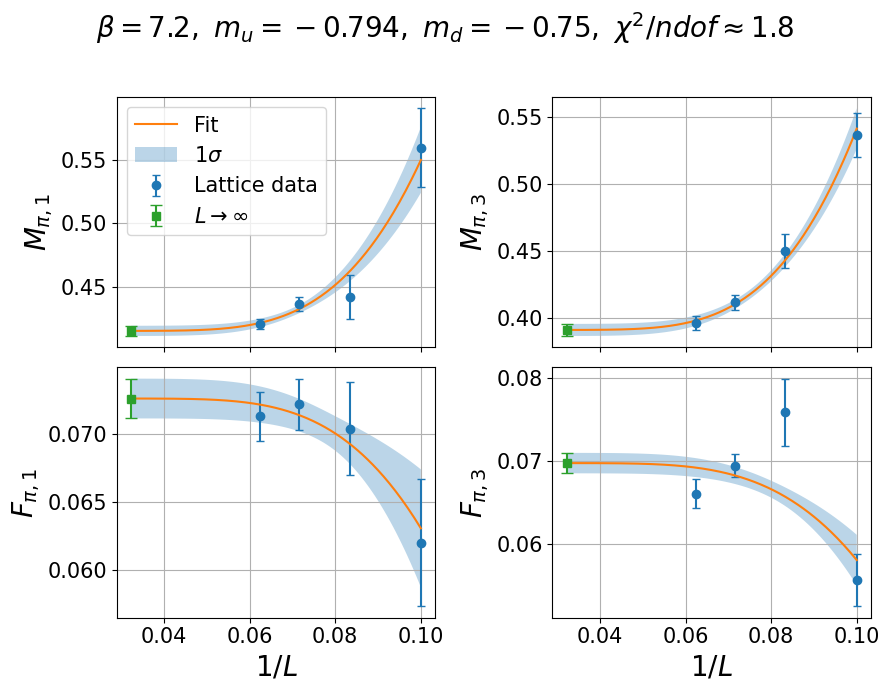

In [399]:
#Plot with inverse 1/L axis

# Plot 
L_fit_new = np.linspace(L_array.min(), L_array.max()+15, 400)

#  Fit curves 
Mc_fit = Mc_L(L_fit_new, popt[0], popt[1])
Ma_fit = Ma_L(L_fit_new, popt[0], popt[2], popt[3])
Fa_fit = Fa_L(L_fit_new, popt[0], popt[4], popt[5])
Fc_fit = Fc_L(L_fit_new, popt[0], popt[6], popt[7])

#  Sigma bands 
sig_Mc = sigma_band(Mc_L, L_fit_new, popt, pcov, [0, 1], jac_Mc)
sig_Ma = sigma_band(Ma_L, L_fit_new, popt, pcov, [0, 2, 3], jac_Ma)
sig_Fa = sigma_band(Fa_L, L_fit_new, popt, pcov, [0, 4, 5], jac_Fa)
sig_Fc = sigma_band(Fc_L, L_fit_new, popt, pcov, [0, 6, 7], jac_Fc)


fig, axs = plt.subplots(2, 2, figsize=(9, 7), sharex=True)

plots = [
    (axs[0,1], Mc_array, DMc_array, Mc_fit, sig_Mc, r'$M_{\pi,3}$', Mc_inf_new, d_Mc_inf_new),
    (axs[0,0], Ma_array, DMa_array, Ma_fit, sig_Ma, r'$M_{\pi,1}$', Ma_inf_new, d_Ma_inf_new),
    (axs[1,0], Fa_array, DFa_array, Fa_fit, sig_Fa, r'$F_{\pi,1}$', Fa_inf_new, d_Fa_inf_new),
    (axs[1,1], Fc_array, DFc_array, Fc_fit, sig_Fc, r'$F_{\pi,3}$', Fc_inf_new, d_Fc_inf_new),
]

x_array = 1.0 / L_array
x_fit   = 1.0 / L_fit_new

x_left = x_fit.min()

#for ax, y, dy, yfit, sig, label in plots:
#    ax.errorbar(x_array, y, yerr=3*dy, fmt='o', capsize=3)
#    ax.plot(x_fit, yfit)
#    ax.fill_between(x_fit, yfit - sig, yfit + sig, alpha=0.3)
#    ax.set_ylabel(label)
#    ax.grid()

for ax, y, dy, yfit, sig, label, yinf, dyinf in plots:
    ax.errorbar(x_array, y, yerr=1*dy, fmt='o', capsize=3, label = 'Lattice data')
    ax.plot(x_fit, yfit, label = 'Fit')
    ax.fill_between(x_fit, yfit - 1*sig, yfit + 1*sig, alpha=0.3, label = r'$1\sigma$')

    # Infinite-volume point
    ax.errorbar(
        x_left, yinf,
        yerr=1*dyinf,
        fmt='s', capsize=4, markersize=6, zorder=5, label=r'$L\rightarrow\infty$'
    )

    ax.set_ylabel(label, fontsize=20)
    ax.grid()
    ax.tick_params(axis='y', labelsize=15)
    ax.tick_params(axis='x', labelsize=15)
    if ax == axs[0,0]:
        ax.legend(fontsize = 15, loc='upper left')



axs[1,0].set_xlabel(r"$1/L$", fontsize=20)
axs[1,1].set_xlabel(r"$1/L$", fontsize=20)

# Header
#fig.suptitle(
#    rf"$point \ {index}. \beta = {beta},\ m_u = {mu},\ m_d = {md}$, with 3$\sigma$ errors. chi2/dof  = {chi2/ndof:.2f}."
#    rf" Green point - inf. vol. value",
#    fontsize=13
#)


fig.suptitle(
  rf"$ \beta = {beta},\ m_u = {mu},\ m_d = {md}, \ \chi^2/ndof \approx 1.8 $", fontsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.95])



##### save figure
def fmt(x):
    """Compact float formatting for filenames."""
    return f"{x:.4g}".replace('.', 'p')  # 0.125 -> 0p125 (filesystem-safe)

beta_s = fmt(beta)
mu_s   = fmt(mu)
md_s   = fmt(md)

#filename = f"/Users/daniilkrichevskiy/Desktop/Infinite_volume_fit/Saved fits/{index}_finite_volume_fit_beta{beta_s}_mu{mu_s}_md{md_s}.png"


#fig.savefig(filename, dpi=300, bbox_inches="tight")
#print(f"Saved figure as: {filename}")
#######


plt.savefig('/Users/daniilkrichevskiy/Desktop/New plots/InfVol1.png', dpi=250)
plt.show()

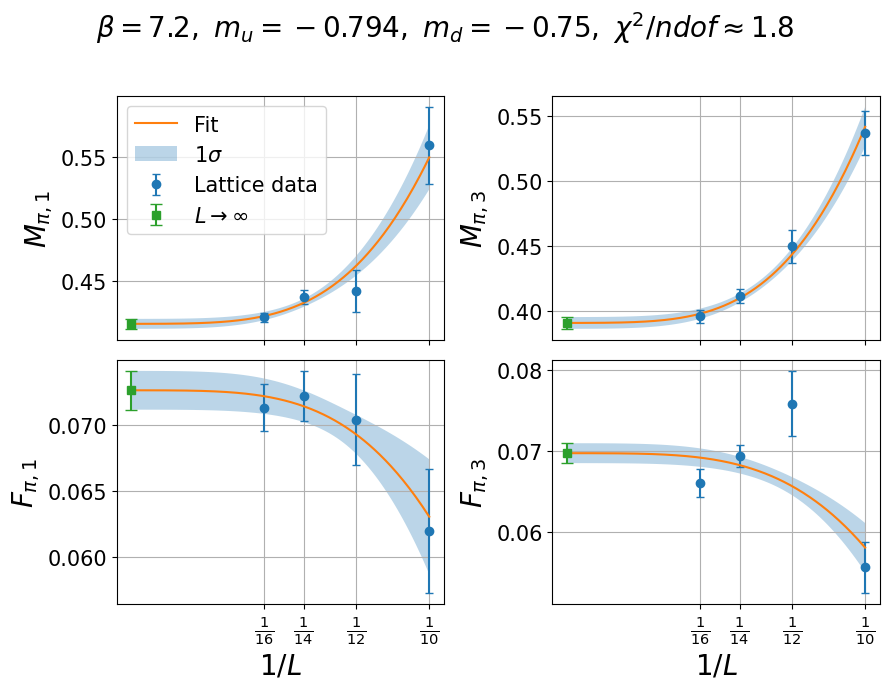

In [401]:
#Plot with inverse 1/L axis

# Plot 
L_fit_new = np.linspace(L_array.min(), L_array.max()+15, 400)

#  Fit curves 
Mc_fit = Mc_L(L_fit_new, popt[0], popt[1])
Ma_fit = Ma_L(L_fit_new, popt[0], popt[2], popt[3])
Fa_fit = Fa_L(L_fit_new, popt[0], popt[4], popt[5])
Fc_fit = Fc_L(L_fit_new, popt[0], popt[6], popt[7])

#  Sigma bands 
sig_Mc = sigma_band(Mc_L, L_fit_new, popt, pcov, [0, 1], jac_Mc)
sig_Ma = sigma_band(Ma_L, L_fit_new, popt, pcov, [0, 2, 3], jac_Ma)
sig_Fa = sigma_band(Fa_L, L_fit_new, popt, pcov, [0, 4, 5], jac_Fa)
sig_Fc = sigma_band(Fc_L, L_fit_new, popt, pcov, [0, 6, 7], jac_Fc)


fig, axs = plt.subplots(2, 2, figsize=(9, 7), sharex=True)

plots = [
    (axs[0,1], Mc_array, DMc_array, Mc_fit, sig_Mc, r'$M_{\pi,3}$', Mc_inf_new, d_Mc_inf_new),
    (axs[0,0], Ma_array, DMa_array, Ma_fit, sig_Ma, r'$M_{\pi,1}$', Ma_inf_new, d_Ma_inf_new),
    (axs[1,0], Fa_array, DFa_array, Fa_fit, sig_Fa, r'$F_{\pi,1}$', Fa_inf_new, d_Fa_inf_new),
    (axs[1,1], Fc_array, DFc_array, Fc_fit, sig_Fc, r'$F_{\pi,3}$', Fc_inf_new, d_Fc_inf_new),
]

x_array = 1.0 / L_array
x_fit   = 1.0 / L_fit_new

# Sort L values (important if not ordered)
L_unique = np.sort(np.unique(L_array))
x_ticks = 1.0 / L_unique

# Create LaTeX-style fraction labels
x_labels = [rf"$\frac{{1}}{{{int(L)}}}$" for L in L_unique]

x_left = x_fit.min()

#for ax, y, dy, yfit, sig, label in plots:
#    ax.errorbar(x_array, y, yerr=3*dy, fmt='o', capsize=3)
#    ax.plot(x_fit, yfit)
#    ax.fill_between(x_fit, yfit - sig, yfit + sig, alpha=0.3)
#    ax.set_ylabel(label)
#    ax.grid()

for ax, y, dy, yfit, sig, label, yinf, dyinf in plots:
    ax.errorbar(x_array, y, yerr=1*dy, fmt='o', capsize=3, label = 'Lattice data')
    ax.plot(x_fit, yfit, label = 'Fit')
    ax.fill_between(x_fit, yfit - 1*sig, yfit + 1*sig, alpha=0.3, label = r'$1\sigma$')

    # Infinite-volume point
    ax.errorbar(
        x_left, yinf,
        yerr=1*dyinf,
        fmt='s', capsize=4, markersize=6, zorder=5, label=r'$L\rightarrow\infty$'
    )

    ax.set_ylabel(label, fontsize=20)
    ax.grid()
    ax.tick_params(axis='y', labelsize=15)
    ax.tick_params(axis='x', labelsize=15)
    if ax == axs[0,0]:
        ax.legend(fontsize = 15, loc='upper left')
        
for ax in axs[1, :]:
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, fontsize=15)


axs[1,0].set_xlabel(r"$1/L$", fontsize=20)
axs[1,1].set_xlabel(r"$1/L$", fontsize=20)

# Header
#fig.suptitle(
#    rf"$point \ {index}. \beta = {beta},\ m_u = {mu},\ m_d = {md}$, with 3$\sigma$ errors. chi2/dof  = {chi2/ndof:.2f}."
#    rf" Green point - inf. vol. value",
#    fontsize=13
#)


fig.suptitle(
  rf"$ \beta = {beta},\ m_u = {mu},\ m_d = {md}, \ \chi^2/ndof \approx 1.8 $", fontsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.95])



##### save figure
def fmt(x):
    """Compact float formatting for filenames."""
    return f"{x:.4g}".replace('.', 'p')  # 0.125 -> 0p125 (filesystem-safe)

beta_s = fmt(beta)
mu_s   = fmt(mu)
md_s   = fmt(md)

#filename = f"/Users/daniilkrichevskiy/Desktop/Infinite_volume_fit/Saved fits/{index}_finite_volume_fit_beta{beta_s}_mu{mu_s}_md{md_s}.png"


#fig.savefig(filename, dpi=300, bbox_inches="tight")
#print(f"Saved figure as: {filename}")
#######


plt.savefig('/Users/daniilkrichevskiy/Desktop/New plots/InfVol1.png', dpi=250)
plt.show()

# Loop to fill in the table

In [274]:
file_path_Kulkarni_latticeresults = '/Users/daniilkrichevskiy/Desktop/Project SIMP at NLO/Fit the LECs/Infinite_volume_fit/Data/latticeresults.csv'
file_path_Kulkarni_smallerlattices = '/Users/daniilkrichevskiy/Desktop/Project SIMP at NLO/Fit the LECs/Infinite_volume_fit/Data/smallerlattices.csv'
file_path_new_data_from_Fabian = '/Users/daniilkrichevskiy/Desktop/Project SIMP at NLO/Fit the LECs/Infinite_volume_fit/Data/new_data_from_Fabian.csv'


data_Kulkarni_latticeresults =  np.loadtxt(file_path_Kulkarni_latticeresults , delimiter = ',', skiprows = 1) # Use skip_header=1 to skip the header row
data_Kulkarni_smallerlattices =  np.loadtxt(file_path_Kulkarni_smallerlattices, delimiter = ',', skiprows = 1) # Use skip_header=1 to skip the header row
data_new_data_from_Fabian =  np.loadtxt(file_path_new_data_from_Fabian, delimiter = ';', skiprows = 1) # Use skip_header=1 to skip the header row



#this is our old data (used in the first version of the paper)
file_path_Kulkarni_current_version = '/Users/daniilkrichevskiy/Desktop/Project SIMP at NLO/Fit the LECs/data/Full_data_Kulkarni/latticeresultsKulkarniFull.csv'
data_Kulkarni_current_version =  np.loadtxt(file_path_Kulkarni_current_version , delimiter = ';', skiprows = 1) # Use skip_header=1 if you want to skip the header row



beta_array = np.array([6.9, 6.9, 6.9, 6.9, 6.9, 7.05, 7.05, 7.05, 7.05, 7.2, 7.2, 7.2, 7.2, 7.2])
mu_array = np.array([-0.92, -0.92, -0.92, -0.92, -0.92, -0.85, -0.85, -0.85, -0.85, -0.794, -0.794, -0.794, -0.794, -0.794])
md_array = np.array([-0.85, -0.88, -0.9, -0.91, -0.92, -0.75, -0.8, -0.83, -0.85, -0.7, -0.75, -0.77, -0.78, -0.794])

len_array = len(beta_array)

#target values

Mc_inf_new_array = []
d_Mc_inf_new_array = []


Ma_inf_new_array = []
d_Ma_inf_new_array = []

Fa_inf_new_array = []
d_Fa_inf_new_array = []

Fc_inf_new_array = []
d_Fc_inf_new_array = []
chi2_over_dof_array = []


#arrays to save the actual values of ensemble parameters (to find what to change in the end)
beta_array_change = []
mu_array_change = []
md_array_change = []

In [276]:
for index in range(len_array):
    beta = beta_array[index]
    mu = mu_array[index]
    md = md_array[index]

# find the additional points
    mask_lattice = (
    np.isclose(data_Kulkarni_latticeresults[:, 2], beta, atol=1e-8) &
    np.isclose(data_Kulkarni_latticeresults[:, 3], mu, atol=1e-8) &
    np.isclose(data_Kulkarni_latticeresults[:, 4], md, atol=1e-8))

    mask_small = (np.isclose(data_Kulkarni_smallerlattices[:, 2], beta, atol=1e-6) & 
    np.isclose(data_Kulkarni_smallerlattices[:, 3], mu, atol=1e-6) &
    np.isclose(data_Kulkarni_smallerlattices[:, 4], md, atol=1e-6))

    mask_Fabian = (
    np.isclose(data_new_data_from_Fabian[:, 2], beta, atol=1e-6) &
    np.isclose(data_new_data_from_Fabian[:, 3], mu, atol=1e-6) &
    np.isclose(data_new_data_from_Fabian[:, 4], md, atol=1e-6))
    ###
    selected_lattice = data_Kulkarni_latticeresults[mask_lattice]
    selected_small   = data_Kulkarni_smallerlattices[mask_small]
    selected_Fabian   = data_new_data_from_Fabian[mask_Fabian]
    
    #choose the columns we need
    selected_lattice = selected_lattice[:, np.r_[0:9, 13:17]]
    selected_small = selected_small[:, np.r_[0:9, 13:17]]
    selected_Fabian = selected_Fabian[:, np.r_[0:9, 13:17]]
    
    final_table = np.vstack((selected_lattice, selected_small, selected_Fabian))
    
    #delete the rows with NaN
    
    if index == 4:
        final_table = final_table[final_table[:, 0] != 12] # get rid of bad data row from Fabian's data with L = 12 
    
    L_array = final_table[:,0]

    Ma_array = final_table[:,5]
    DMa_array = final_table[:,6]

    Mc_array = final_table[:,7]
    DMc_array = final_table[:,8]

    Fa_array = final_table[:,9]
    DFa_array = final_table[:,10]

    Fc_array = final_table[:,11]
    DFc_array = final_table[:,12]

    #print(final_table.shape[0])

    if final_table.shape[0] > 1:  #perform the fit only if we have more then one point

        beta_array_change.append(beta)
        mu_array_change.append(mu)
        md_array_change.append(md)

        #prepare the data for the fit
        xdata = L_array
    
        Y_all = np.concatenate((Mc_array, Ma_array, Fa_array, Fc_array))
    
        DY_all = np.concatenate((DMc_array, DMa_array, DFa_array, DFc_array))

        mask = ~np.isnan(Y_all) & ~np.isnan(DY_all)

        Y_all_clean = Y_all[mask]
        DY_all_clean = DY_all[mask]

        def joint_model_clean(L, *params):
            full = joint_model(L, *params)
            return full[mask]
    
        p0 = [np.nanmean(Mc_array), 0.1, np.nanmean(Ma_array), 0.1, np.nanmean(Fa_array), 0.1, np.nanmean(Fc_array), 0.1]
    
        #perform the fit
    
        popt, pcov = curve_fit(
            joint_model_clean,
            L_array,
            Y_all_clean,
            sigma=DY_all_clean,
            p0=p0,
            absolute_sigma=True
        )
        
        errors = np.sqrt(np.diag(pcov))

        #save the results of the fit
        Mc_inf_new =  popt[0]
        Mc_inf_new_array.append(Mc_inf_new)
        
        d_Mc_inf_new = errors[0]
        d_Mc_inf_new_array.append(d_Mc_inf_new)
        
        Ma_inf_new = popt[2]
        Ma_inf_new_array.append(Ma_inf_new)
        
        d_Ma_inf_new = errors[2]
        d_Ma_inf_new_array.append(d_Ma_inf_new)
        
        Fa_inf_new = popt[4]
        Fa_inf_new_array.append(Fa_inf_new)
        
        d_Fa_inf_new = errors[4]
        d_Fa_inf_new_array.append(d_Fa_inf_new)
        
        Fc_inf_new = popt[6]
        Fc_inf_new_array.append(Fc_inf_new) 

        d_Fc_inf_new = errors[6]
        d_Fc_inf_new_array.append(d_Fc_inf_new)

        #chi2 over dof
        residuals = Y_all_clean - joint_model_clean(L_array, *popt)

        chi2 = np.sum((residuals / DY_all_clean)**2)
        ndof = len(Y_all_clean) - len(popt)

        if ndof == 0:
            chi2_over_ndof = 'NaN'
        else:
            chi2_over_ndof = chi2/ndof
            
        chi2_over_dof_array.append(chi2_over_ndof)

## We can now replace the values in the dataset data_Kulkarni_current_version

In [279]:
indices_of_rows_to_replace = []
for beta, mu, md in zip(beta_array_change, mu_array_change, md_array_change):
    
    
    mask_data_Kulkarni_current_version = (
    np.isclose(data_Kulkarni_current_version[:, 0], beta, atol=1e-8) &
    np.isclose(data_Kulkarni_current_version[:, 1], mu, atol=1e-8) &
    np.isclose(data_Kulkarni_current_version[:, 2], md, atol=1e-8))

    #print(mask_data_Kulkarni_latticeresults)
    
    idx = np.argmax(mask_data_Kulkarni_current_version)
    indices_of_rows_to_replace.append(idx)

print(indices_of_rows_to_replace)

[39, 41, 42, 43, 49, 50, 51, 52, 58, 59, 60, 62]


In [281]:
for index_change, row_index in enumerate(indices_of_rows_to_replace):
    data_Kulkarni_current_version[row_index, 3] = Ma_inf_new_array[index_change]
    data_Kulkarni_current_version[row_index, 4] = d_Ma_inf_new_array[index_change]
    data_Kulkarni_current_version[row_index, 5] = Mc_inf_new_array[index_change]
    data_Kulkarni_current_version[row_index, 6] = d_Mc_inf_new_array[index_change]
    data_Kulkarni_current_version[row_index, 7] = Fa_inf_new_array[index_change]
    data_Kulkarni_current_version[row_index, 8] = d_Fa_inf_new_array[index_change]
    data_Kulkarni_current_version[row_index, 9] = Fc_inf_new_array[index_change]
    data_Kulkarni_current_version[row_index, 10] = d_Fc_inf_new_array[index_change]

In [283]:
#Now we have to replace the data in the rows which are left by hand  
#this are 2 points with index 1 and 12. Moreover, point with index = 8 should be treated as it has only one point 
#because the fit is extremely bad
# we just inflate the errors 

#point 1
percent_1 = 0.02
row_index_1 = 40 # for index 1

new_mass_A_error_1 = percent_1 *  data_Kulkarni_current_version[row_index_1, 3]
current_mass_A_error_1 =  data_Kulkarni_current_version[row_index_1, 4]
data_Kulkarni_current_version[row_index_1, 4] = np.sqrt(current_mass_A_error_1**2 + new_mass_A_error_1**2)

new_mass_C_error_1 = percent_1 *  data_Kulkarni_current_version[row_index_1, 5]
current_mass_C_error_1 =  data_Kulkarni_current_version[row_index_1, 6]
data_Kulkarni_current_version[row_index_1, 6] = np.sqrt(current_mass_C_error_1**2 + new_mass_C_error_1**2)

new_f_A_error_1 = 2 * percent_1 *  data_Kulkarni_current_version[row_index_1, 7]
current_f_A_error_1 = data_Kulkarni_current_version[row_index_1, 8]
data_Kulkarni_current_version[row_index_1, 8] = np.sqrt(current_f_A_error_1**2 + new_f_A_error_1**2)

new_f_C_error_1 = 2 * percent_1 *  data_Kulkarni_current_version[row_index_1, 9]
current_f_C_error_1 = data_Kulkarni_current_version[row_index_1, 10]
data_Kulkarni_current_version[row_index_1, 10] = np.sqrt(current_f_C_error_1**2 + new_f_C_error_1**2)


#point 2
percent_12 = 0.1
row_index_12 = 61 # for index 12

new_mass_A_error_12 = percent_12 *  data_Kulkarni_current_version[row_index_12, 3]
current_mass_A_error_12 =  data_Kulkarni_current_version[row_index_12, 4]
data_Kulkarni_current_version[row_index_12, 4] = np.sqrt(current_mass_A_error_12**2 + new_mass_A_error_12**2)

new_mass_C_error_12 = percent_12 *  data_Kulkarni_current_version[row_index_12, 5]
current_mass_C_error_12 =  data_Kulkarni_current_version[row_index_12, 6]
data_Kulkarni_current_version[row_index_12, 6] = np.sqrt(current_mass_C_error_12**2 + new_mass_C_error_12**2)

new_f_A_error_12 = 2 * percent_12 *  data_Kulkarni_current_version[row_index_12, 7]
current_f_A_error_12 = data_Kulkarni_current_version[row_index_12, 8]
data_Kulkarni_current_version[row_index_12, 8] = np.sqrt(current_f_A_error_12**2 + new_f_A_error_12**2)

new_f_C_error_12 = 2 * percent_12 *  data_Kulkarni_current_version[row_index_12, 9]
current_f_C_error_12 = data_Kulkarni_current_version[row_index_12, 10]
data_Kulkarni_current_version[row_index_12, 10] = np.sqrt(current_f_C_error_12**2 + new_f_C_error_12**2)


#point 3
percent_8 = 0.1
row_index_8 = 52 # for index 8

new_mass_A_error_8 = percent_8 *  data_Kulkarni_current_version[row_index_8, 3]
current_mass_A_error_8 =  data_Kulkarni_current_version[row_index_8, 4]
data_Kulkarni_current_version[row_index_8, 4] = np.sqrt(current_mass_A_error_8**2 + new_mass_A_error_8**2)

new_mass_C_error_8 = percent_8 *  data_Kulkarni_current_version[row_index_8, 5]
current_mass_C_error_8 =  data_Kulkarni_current_version[row_index_8, 6]
data_Kulkarni_current_version[row_index_8, 6] = np.sqrt(current_mass_C_error_8**2 + new_mass_C_error_8**2)

new_f_A_error_8 = 2 * percent_8 *  data_Kulkarni_current_version[row_index_8, 7]
current_f_A_error_8 = data_Kulkarni_current_version[row_index_8, 8]
data_Kulkarni_current_version[row_index_8, 8] = np.sqrt(current_f_A_error_8**2 + new_f_A_error_8**2)

new_f_C_error_8 = 2 * percent_8 *  data_Kulkarni_current_version[row_index_8, 9]
current_f_C_error_8 = data_Kulkarni_current_version[row_index_8, 10]
data_Kulkarni_current_version[row_index_8, 10] = np.sqrt(current_f_C_error_8**2 + new_f_C_error_8**2)

In [285]:
header = "β;mu;md;mπ^A;Δmπ^A;mπ^C;Δmπ^C;fπ^A;Δfπ^A;fπ^C;Δfπ^C;mAWI;ΔmAWI"

np.savetxt(
    "/Users/daniilkrichevskiy/Desktop/Project SIMP at NLO/Fit the LECs/Infinite_volume_fit/Data/latticeresultsKulkarniFull_InfiniteVolume.csv",
    data_Kulkarni_current_version,
    delimiter=";",
    header=header,
    comments="",
    encoding="utf-8"
)

In [289]:
chi2_over_dof_array

[1.576335118166102,
 0.6417572348784086,
 1.97940679967568,
 0.40603795892902206,
 0.9716334961615035,
 1.2117582996828118,
 0.5675717076712302,
 23.827223206174768,
 1.3564082799721646,
 1.771199378922789,
 3.431020964419055,
 4.524232351991509]